# 01 — Exploratory Data Analysis: Tennessee Eastman Process (TEP)

This notebook covers Phase 1 (EDA) on the TEP fault diagnosis dataset.

**Dataset background:** The Tennessee Eastman Process is a simulated industrial chemical
process (Downs & Vogel, 1993) widely used as a benchmark for fault detection and diagnosis.
The commonly distributed version (Rieth et al., 2017) has:
- `faultNumber`: 0 = normal/fault-free operation, 1–20 = different fault types
- `simulationRun`: which simulation run this row belongs to (think of this as a "batch ID")
- `sample`: the time step within that run
- `xmeas_1` ... `xmeas_41`: 41 continuous process measurements (temperatures, flows, pressures, compositions)
- `xmv_1` ... `xmv_11`: 11 manipulated variables (valve positions / control actions)

**IMPORTANT — verify before running:** column names can differ slightly depending on
where you downloaded the dataset (some versions use `Fault`, `Run`, `Sample`, or
lowercase/uppercase variants). The very first code cell prints your actual columns —
read that output and adjust the `FAULT_COL`, `RUN_COL`, `SAMPLE_COL` variables below if needed.


In [13]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

pd.set_option('display.max_columns', 60)
sns.set_style('whitegrid')


In [14]:
# ── Load the data ────────────────────────────────────────────────────────
# TODO: point this to wherever your TEP CSV/RData-converted file actually lives.
# If you have separate fault-free and faulty files, load both and concat (see commented block).

DATA_PATH = "../data/processed/TEP_Random_Sample_5_percent.csv" 

df = pd.read_csv(DATA_PATH)

# If you have separate files instead of one combined CSV, use this pattern instead:
# df_normal = pd.read_csv("../data/raw/TEP_FaultFree_Training.csv")
# df_faulty = pd.read_csv("../data/raw/TEP_Faulty_Training.csv")
# df = pd.concat([df_normal, df_faulty], ignore_index=True)

print("Shape:", df.shape)
df.head()


Shape: (250000, 55)


,faultNumber,simulationRun,sample,xmeas_1,xmeas_2,xmeas_3,xmeas_4,xmeas_5,xmeas_6,xmeas_7,xmeas_8,xmeas_9,xmeas_10,xmeas_11,xmeas_12,xmeas_13,xmeas_14,xmeas_15,xmeas_16,xmeas_17,xmeas_18,xmeas_19,xmeas_20,xmeas_21,xmeas_22,xmeas_23,xmeas_24,xmeas_25,xmeas_26,xmeas_27,xmeas_28,xmeas_29,xmeas_30,xmeas_31,xmeas_32,xmeas_33,xmeas_34,xmeas_35,xmeas_36,xmeas_37,xmeas_38,xmeas_39,xmeas_40,xmeas_41,xmv_1,xmv_2,xmv_3,xmv_4,xmv_5,xmv_6,xmv_7,xmv_8,xmv_9,xmv_10,xmv_11
0,16,358,389,0.19550,3706.6,4527.8,9.4729,27.045,42.186,2708.7,75.039,120.42,0.33535,80.173,49.918,2637.8,23.562,49.078,3103.6,23.118,66.971,257.13,344.27,94.383,77.491,32.643,8.8719,26.012,6.8239,18.519,1.6512,33.392,13.717,23.481,1.1497,18.279,2.2885,4.8658,2.3444,0.023000,0.79413,0.104210,53.016,44.051,64.072,54.195,19.694,59.568,22.777,39.374,37.859,44.401,52.057,41.665,17.555
1,8,500,433,0.32124,3632.8,4126.4,9.5008,27.153,42.610,2568.8,70.159,120.41,0.37645,82.879,50.120,2496.4,24.149,47.633,2963.1,22.919,72.625,384.73,341.65,94.957,78.042,34.283,9.2346,21.201,6.8978,20.700,1.7026,35.799,14.247,15.937,1.5909,22.335,2.3376,5.4833,2.6181,0.028470,0.99224,0.079803,53.752,43.300,61.260,49.658,31.846,65.443,20.055,46.027,38.453,41.057,99.839,40.237,18.562
2,10,410,401,0.28359,3676.0,4463.6,9.3608,27.430,42.523,2709.3,73.718,120.41,0.32854,79.979,48.268,2637.3,23.614,50.207,3107.6,23.282,63.179,213.51,339.49,94.607,77.222,32.167,8.8868,26.258,6.7824,18.743,1.6409,32.643,13.799,24.397,1.3309,18.760,2.2595,4.9194,2.1970,0.019261,0.92434,0.111950,53.533,43.307,63.536,54.274,27.699,61.496,22.180,39.476,33.004,47.012,40.351,41.937,17.445
3,1,443,498,0.75021,3577.9,4491.9,8.8251,26.652,42.190,2688.3,75.191,120.39,0.33165,80.310,49.527,2617.3,24.340,48.645,3087.6,23.772,68.033,269.77,338.60,94.994,77.598,31.637,8.9778,25.620,6.9336,19.143,1.7456,32.754,13.736,23.414,1.3672,19.031,2.3853,4.9832,2.3586,0.015435,0.84705,0.093910,53.277,43.347,62.309,53.335,73.874,55.873,21.250,40.184,36.709,43.399,59.654,40.459,16.068
4,9,64,466,0.28790,3625.6,4515.1,9.2841,26.802,42.420,2708.4,75.111,120.40,0.32692,80.042,48.485,2637.0,25.791,50.472,3105.3,23.423,65.491,228.44,340.83,94.790,77.205,32.061,8.8185,26.336,6.7810,18.725,1.6283,33.081,13.910,23.804,1.1376,18.791,2.2238,4.7540,2.2750,0.028630,0.85454,0.091765,54.183,44.235,61.856,54.158,27.825,61.416,22.161,39.183,33.640,47.625,46.648,41.256,17.063


In [15]:
# ── Verify column names — READ THIS OUTPUT CAREFULLY ────────────────────
print(list(df.columns))


['faultNumber', 'simulationRun', 'sample', 'xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5', 'xmeas_6', 'xmeas_7', 'xmeas_8', 'xmeas_9', 'xmeas_10', 'xmeas_11', 'xmeas_12', 'xmeas_13', 'xmeas_14', 'xmeas_15', 'xmeas_16', 'xmeas_17', 'xmeas_18', 'xmeas_19', 'xmeas_20', 'xmeas_21', 'xmeas_22', 'xmeas_23', 'xmeas_24', 'xmeas_25', 'xmeas_26', 'xmeas_27', 'xmeas_28', 'xmeas_29', 'xmeas_30', 'xmeas_31', 'xmeas_32', 'xmeas_33', 'xmeas_34', 'xmeas_35', 'xmeas_36', 'xmeas_37', 'xmeas_38', 'xmeas_39', 'xmeas_40', 'xmeas_41', 'xmv_1', 'xmv_2', 'xmv_3', 'xmv_4', 'xmv_5', 'xmv_6', 'xmv_7', 'xmv_8', 'xmv_9', 'xmv_10', 'xmv_11']


In [16]:
# ── Set these to match your actual column names (adjust if printed names differ) ──
FAULT_COL  = "faultNumber"
RUN_COL    = "simulationRun"
SAMPLE_COL = "sample"

feature_cols = [c for c in df.columns if c.startswith("xmeas_") or c.startswith("xmv_")]
print(f"Found {len(feature_cols)} feature columns (expect 52: 41 xmeas + 11 xmv)")
print(feature_cols[:5], "...")


Found 52 feature columns (expect 52: 41 xmeas + 11 xmv)
['xmeas_1', 'xmeas_2', 'xmeas_3', 'xmeas_4', 'xmeas_5'] ...


In [17]:
# ── Basic structure checks ───────────────────────────────────────────────
print("Dtypes:\n", df.dtypes.value_counts())
print("\nMissing values per column (top 10):")
print(df.isna().sum().sort_values(ascending=False).head(10))
print("\nNumber of unique simulation runs:", df[RUN_COL].nunique())
print("Samples per run (should be consistent):", df.groupby(RUN_COL).size().describe())


Dtypes:
 float64    52
int64       3
Name: count, dtype: int64

Missing values per column (top 10):
faultNumber    0
xmeas_39       0
xmeas_28       0
xmeas_29       0
xmeas_30       0
xmeas_31       0
xmeas_32       0
xmeas_33       0
xmeas_34       0
xmeas_35       0
dtype: int64

Number of unique simulation runs: 500
Samples per run (should be consistent): count    500.000000
mean     500.000000
std       21.856977
min      430.000000
25%      484.000000
50%      500.000000
75%      515.000000
max      567.000000
dtype: float64


faultNumber
1     12500
2     12379
3     12606
4     12422
5     12606
6     12433
7     12707
8     12346
9     12640
10    12258
11    12369
12    12679
13    12502
14    12556
15    12663
16    12495
17    12309
18    12457
19    12476
20    12597
Name: count, dtype: int64


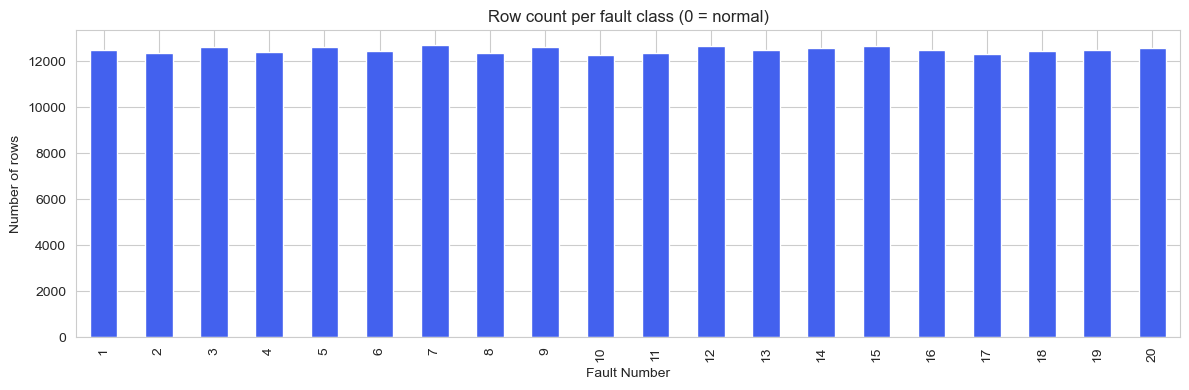

In [18]:
# ── Target class distribution ────────────────────────────────────────────
fault_counts = df[FAULT_COL].value_counts().sort_index()
print(fault_counts)

plt.figure(figsize=(12, 4))
fault_counts.plot(kind='bar', color='#4361ee')
plt.title('Row count per fault class (0 = normal)')
plt.xlabel('Fault Number')
plt.ylabel('Number of rows')
plt.tight_layout()
plt.show()


In [19]:
# ── Summary statistics on the process variables ─────────────────────────
df[feature_cols].describe().T


,count,mean,std,min,25%,50%,75%,max
xmeas_1,250000.0,0.261604,0.149413,-0.003704,0.218550,0.251260,0.283190,1.015100
xmeas_2,250000.0,3663.607601,43.019504,3372.300000,3636.400000,3663.100000,3690.000000,3883.100000
xmeas_3,250000.0,4505.780280,110.812911,3711.800000,4469.000000,4508.300000,4547.700000,5110.400000
xmeas_4,250000.0,9.369219,0.364311,6.804000,9.263600,9.354600,9.455900,12.240000
xmeas_5,250000.0,26.901900,0.231748,25.434000,26.760000,26.900000,27.043000,28.304000
xmeas_6,250000.0,42.362999,0.317233,39.924000,42.180000,42.347000,42.524000,44.383000
xmeas_7,250000.0,2722.782121,75.899273,2445.500000,2697.500000,2705.500000,2714.900000,3000.200000
xmeas_8,250000.0,74.881513,1.343167,63.120000,74.427000,74.950000,75.441000,86.435000
xmeas_9,250000.0,120.400251,0.073030,119.660000,120.380000,120.400000,120.420000,120.990000
xmeas_10,250000.0,0.346333,0.085520,0.047757,0.323140,0.336330,0.348710,0.809600


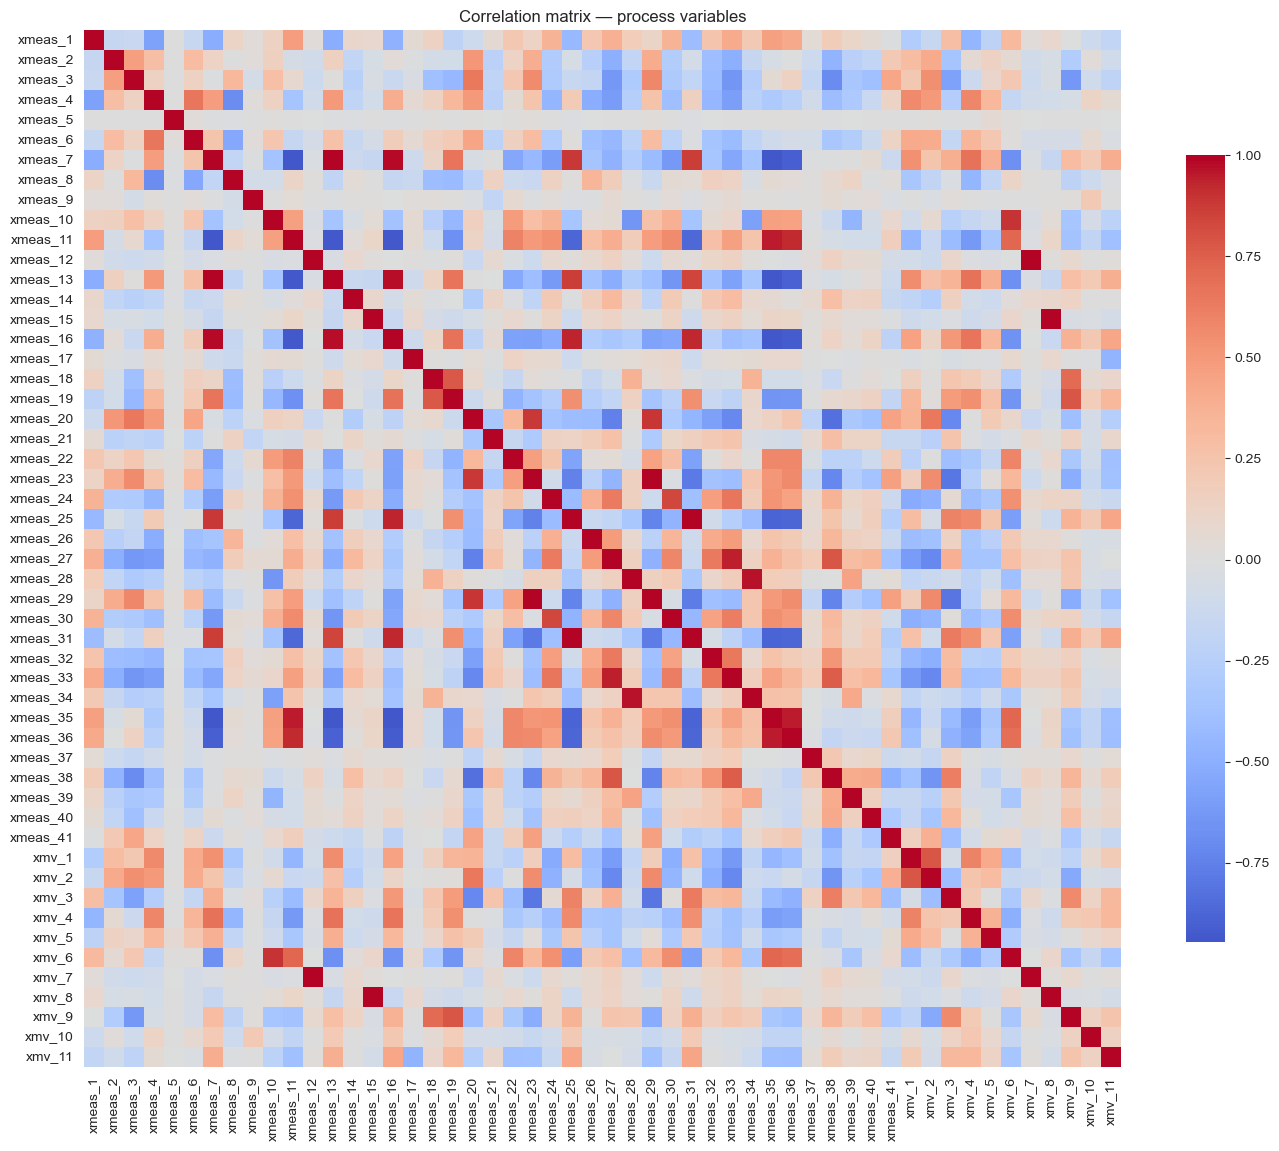

In [20]:
# ── Correlation heatmap (subset — 52 vars is a lot for one heatmap) ─────
plt.figure(figsize=(14, 12))
corr = df[feature_cols].sample(min(20000, len(df)), random_state=42).corr()
sns.heatmap(corr, cmap='coolwarm', center=0, square=True, cbar_kws={'shrink': 0.7})
plt.title('Correlation matrix — process variables')
plt.tight_layout()
plt.show()


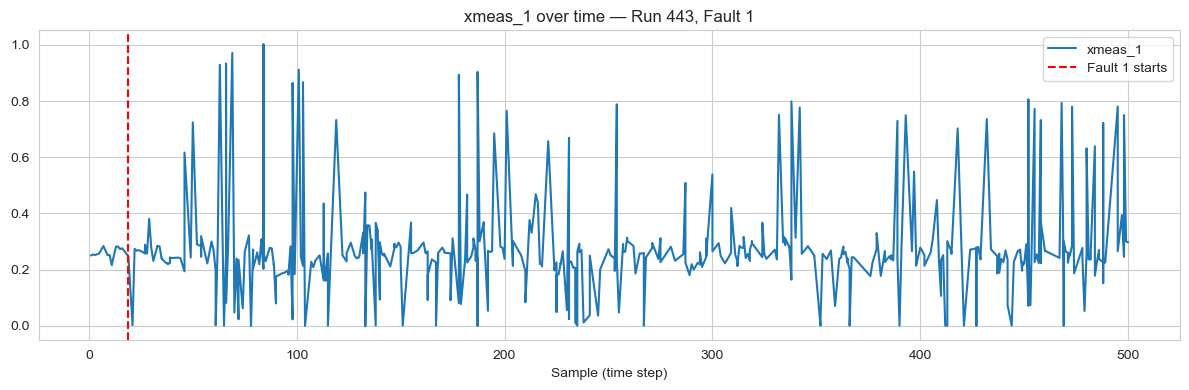

In [21]:
# ── Time series view: how a variable behaves before/after a fault is introduced ──
# Pick one faulty run and one normal run, compare a key variable over time.

example_fault = 1  # change to inspect a different fault type
runs_with_fault = df[df[FAULT_COL] == example_fault][RUN_COL].unique()

if len(runs_with_fault) > 0:
    run_id = runs_with_fault[0]
    run_data = df[(df[RUN_COL] == run_id)].sort_values(SAMPLE_COL)

    plt.figure(figsize=(12, 4))
    plt.plot(run_data[SAMPLE_COL], run_data['xmeas_1'], label='xmeas_1')
    fault_start = run_data[run_data[FAULT_COL] == example_fault][SAMPLE_COL].min()
    plt.axvline(fault_start, color='red', linestyle='--', label=f'Fault {example_fault} starts')
    plt.title(f'xmeas_1 over time — Run {run_id}, Fault {example_fault}')
    plt.xlabel('Sample (time step)')
    plt.legend()
    plt.tight_layout()
    plt.show()
else:
    print(f"No runs found for fault {example_fault} — check your FAULT_COL values")


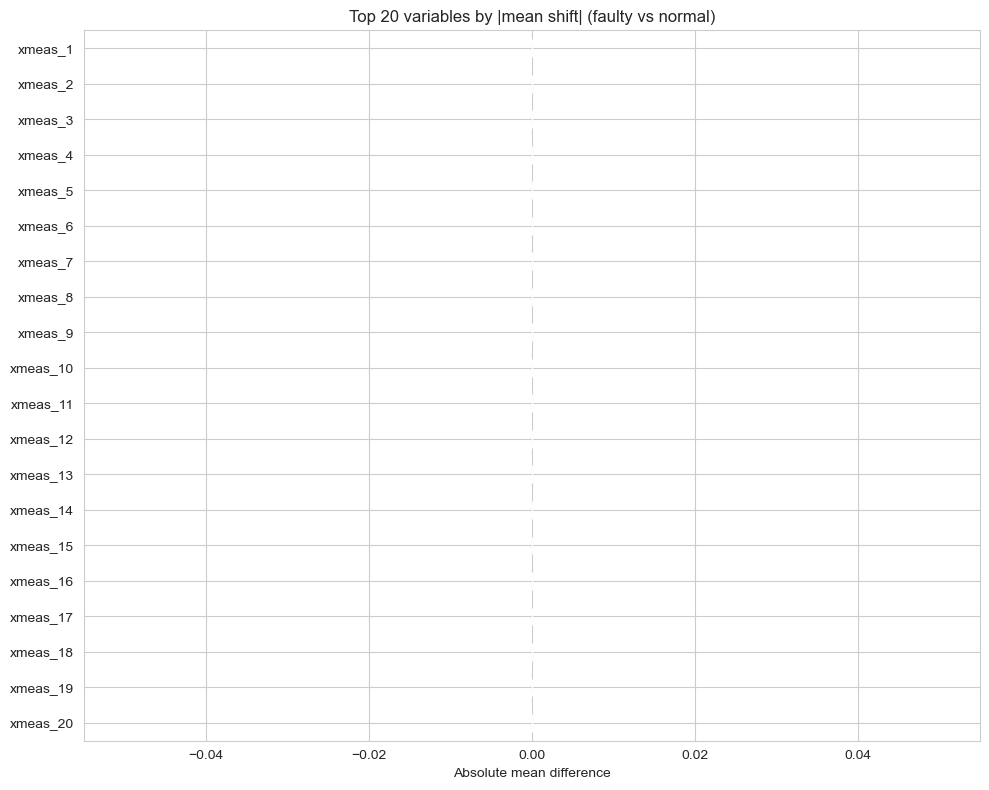

In [22]:
# ── Which variables shift the most between normal and faulty rows? ──────
# A quick signal of which sensors are most informative for classification.

normal_means = df[df[FAULT_COL] == 0][feature_cols].mean()
faulty_means = df[df[FAULT_COL] != 0][feature_cols].mean()
shift = (faulty_means - normal_means).abs().sort_values(ascending=False)

plt.figure(figsize=(10, 8))
shift.head(20).plot(kind='barh', color='#7209b7')
plt.title('Top 20 variables by |mean shift| (faulty vs normal)')
plt.xlabel('Absolute mean difference')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()


## Notes & Next Steps

Write down here, in your own words, 3–5 observations from the plots above
(e.g. "Fault 4 shows almost no signal in any variable — likely a borderline case",
"xmeas_9 and xmeas_18 shift the most overall, candidates as top features").
This is exactly the kind of finding interviewers want to hear about.

**Next notebook:** `02_preprocessing_feature_engineering.ipynb` — splitting the data
correctly (without leakage), scaling, and feature engineering.
